In [5]:
import tensorflow as tf
from tensorflow.data import TFRecordDataset 
import numpy as np
import os
import matplotlib.pyplot as plt
from common import fast_gpu_map,SAMPLERATE,feature_description
from fretboard import FretBoard
from model import build_1d_cnn_model
import common
fretboard=FretBoard(17.5,SAMPLERATE)

BATCH_SIZE=1
recordfile="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/filtered_poly_data.tfrecord"
model_weights="/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/checkpoints/guitarmidi_epoch03_valAcc0.9930_valPrec0.7764_valRecall0.1331.weights.h5"#"/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/guitarmidi.weights.h5"

cnn_model=build_1d_cnn_model(BATCH_SIZE,common.INPUT_SHAPE, common.OUTPUT_DIM_NOTES,training=False)
cnn_model.load_weights(model_weights)
dataset=TFRecordDataset(recordfile)
def parse_example(example_proto):
    return tf.io.parse_single_example(example_proto, feature_description)
# Parse the dataset
dataset = dataset.map(parse_example).shuffle(buffer_size=10000,reshuffle_each_iteration=True)
dataset=dataset.shuffle(1000,reshuffle_each_iteration=True)
dataset=dataset.map(lambda x: fast_gpu_map(x,training=False)).batch(BATCH_SIZE,drop_remainder=True).take(1000).prefetch(tf.data.AUTOTUNE)
#dataset=dataset.map(lambda path: fast_gpu_map(path, training=False)).take(100).prefetch(tf.data.AUTOTUNE)
#dataset = dataset.shuffle(BATCH_SIZE * 2).map(lambda path: fast_gpu_map(path, training=False), num_parallel_calls=tf.data.AUTOTUNE)
labels_true_all=[]
labels_pred_all=[]
total_tp=0
total_fp=0
total_fn=0
for audio,label in dataset:
    # print("Audio shape:", audio.shape)
    pred=cnn_model.predict(audio,verbose=0)
    # print("Pred shape:", pred.shape)
    # print("Label shape:", label.shape)
    label=label.numpy()#.flatten()
    pred=pred#.flatten()
    # print("flat Pred shape:", pred.shape)
    # print("flat Label shape:", label.shape)
    labels_true_all.append(label)
    labels_pred_all.append(pred)
    thresh=0.5
    label_active = label[:88] # Assuming 88 notes
    pred_active = pred[ :88]
    total_tp += np.sum((label_active == 1) & (pred_active > thresh))
    #total_tp+=np.sum((label==1) & (pred>thresh))
    total_fp+=np.sum((label_active==0)&(pred_active>thresh))
    total_fn+=np.sum((label_active==1)&(pred_active<=thresh))

print("Total True Positives:", total_tp)
print("Total False Positives:", total_fp)
print("Total False Negatives:", total_fn)
precision=total_tp/(total_tp+total_fp+1e-8)
recall=total_tp/(total_tp+total_fn+1e-8)
print("Precision:", precision)
print("Recall:", recall)


Initial input shape: (1, 296, 512)
After first Conv2D: (1, 148, 64)
Extracting string from filters 0 to 20
String 0 section shape: (1, 20, 64)
String 0 after first Conv1D: (1, 20, 128)
Extracting string from filters 21 to 40
String 21 section shape: (1, 19, 64)
String 21 after first Conv1D: (1, 19, 128)
Extracting string from filters 41 to 60
String 41 section shape: (1, 19, 64)
String 41 after first Conv1D: (1, 19, 128)
Extracting string from filters 61 to 76
String 61 section shape: (1, 15, 64)
String 61 after first Conv1D: (1, 15, 128)
Extracting string from filters 77 to 96
String 77 section shape: (1, 19, 64)
String 77 after first Conv1D: (1, 19, 128)
Extracting string from filters 97 to 147
String 97 section shape: (1, 50, 64)
String 97 after first Conv1D: (1, 50, 128)
Total True Positives: 5
Total False Positives: 29
Total False Negatives: 1106
Precision: 0.14705882348615917
Recall: 0.004500450044963993


In [6]:
print("Length of labels_true_all:", len(labels_true_all))
labels_true=np.concatenate(labels_true_all,axis=0)
labels_pred=np.concatenate(labels_pred_all,axis=0)
labels_pred=(labels_pred>0.5).astype(np.float32)
print("Shape of labels true:",labels_true.shape)
#compute recall
tp=np.sum((labels_true==1) & (labels_pred==1),axis=0)

fp=np.sum((labels_true==0)&(labels_pred==1),axis=0)

print("Shape of tp",tp.shape)

precision=tp/(tp+fp+1e-8)
print("precision:", precision)
print("True Positives:", tp)
print("False Positives:", fp)

Length of labels_true_all: 1000
Shape of labels true: (1000, 129)
Shape of tp (129,)
precision: [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.5        0.         0.         0.         0.         0.04347826
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.        

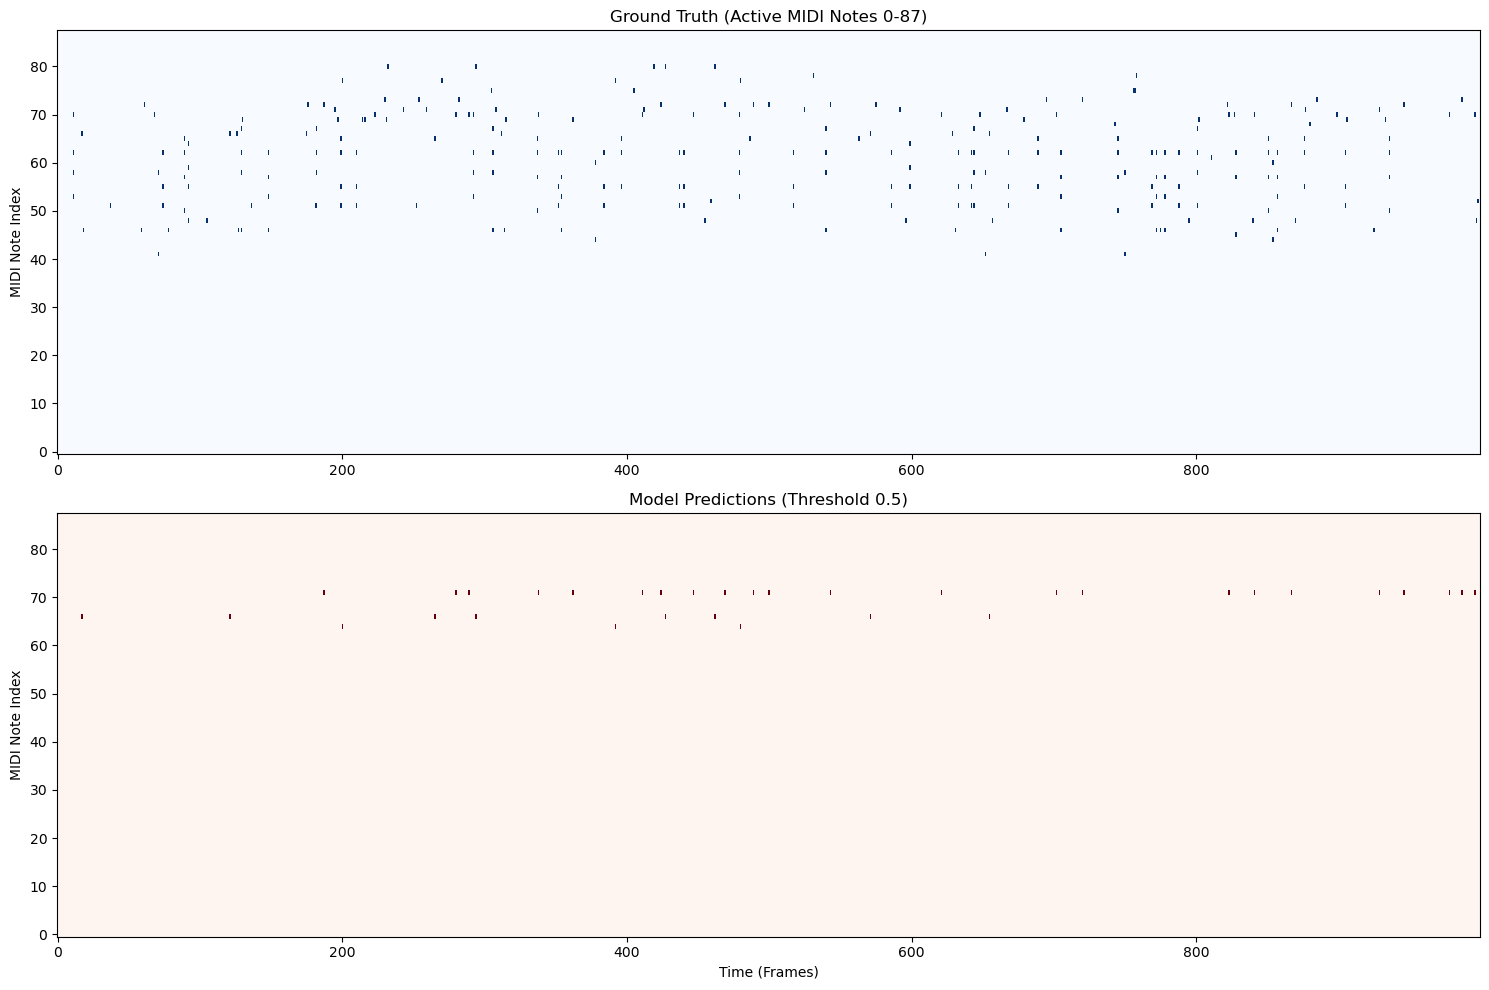

In [7]:
# Convert lists to single arrays
all_true = np.concatenate(labels_true_all, axis=0)[:, :88]
all_pred = np.concatenate(labels_pred_all, axis=0)[:, :88]

# Binary threshold for the plot
all_pred_bin = (all_pred > 0.5).astype(np.float32)

plt.figure(figsize=(15, 10))

# Plot Ground Truth (Blue)
plt.subplot(2, 1, 1)
plt.imshow(all_true.T, aspect='auto', origin='lower', cmap='Blues', interpolation='nearest')
plt.title("Ground Truth (Active MIDI Notes 0-87)")
plt.ylabel("MIDI Note Index")

# Plot Predictions (Red)
plt.subplot(2, 1, 2)
plt.imshow(all_pred_bin.T, aspect='auto', origin='lower', cmap='Reds', interpolation='nearest')
plt.title("Model Predictions (Threshold 0.5)")
plt.ylabel("MIDI Note Index")
plt.xlabel("Time (Frames)")

plt.tight_layout()
plt.show()